In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 6.50MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [ ]:
import pandas as pd
import os

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))
df.head()

['mushrooms.csv']


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Load dataset
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))

# Display first 5 rows
print(df.head())

# Check missing values
print(df.isnull().sum())

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop("class", axis=1)
y = df["class"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree using Entropy (ID3)
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

['mushrooms.csv']
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p     

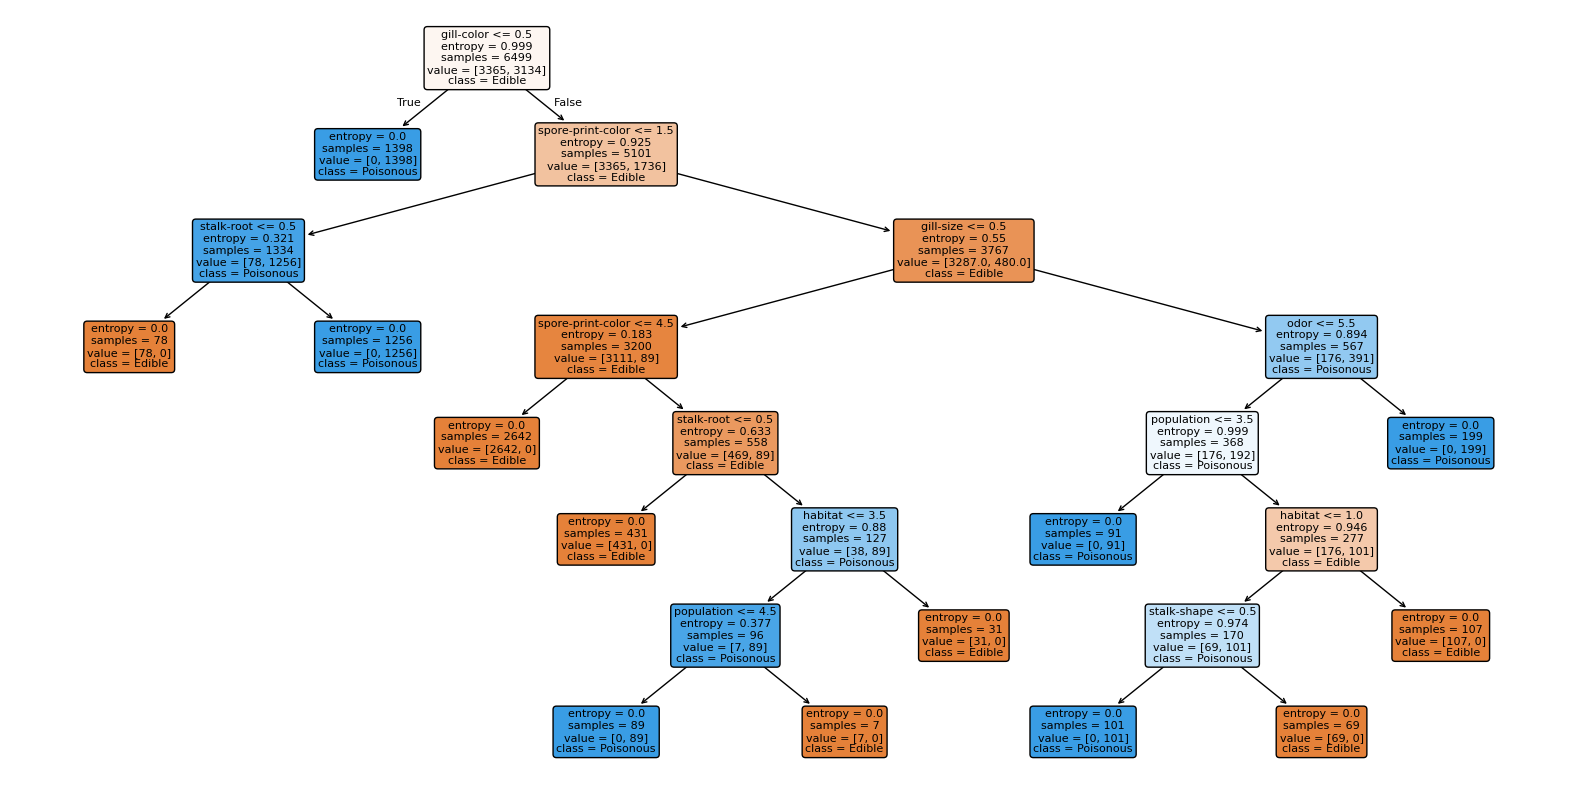

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Edible","Poisonous"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [ ]:
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))
print(df.head())
print(df.info())
print(df.describe())



['mushrooms.csv']
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p     

In [ ]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    criterion="entropy",   # Use Entropy
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

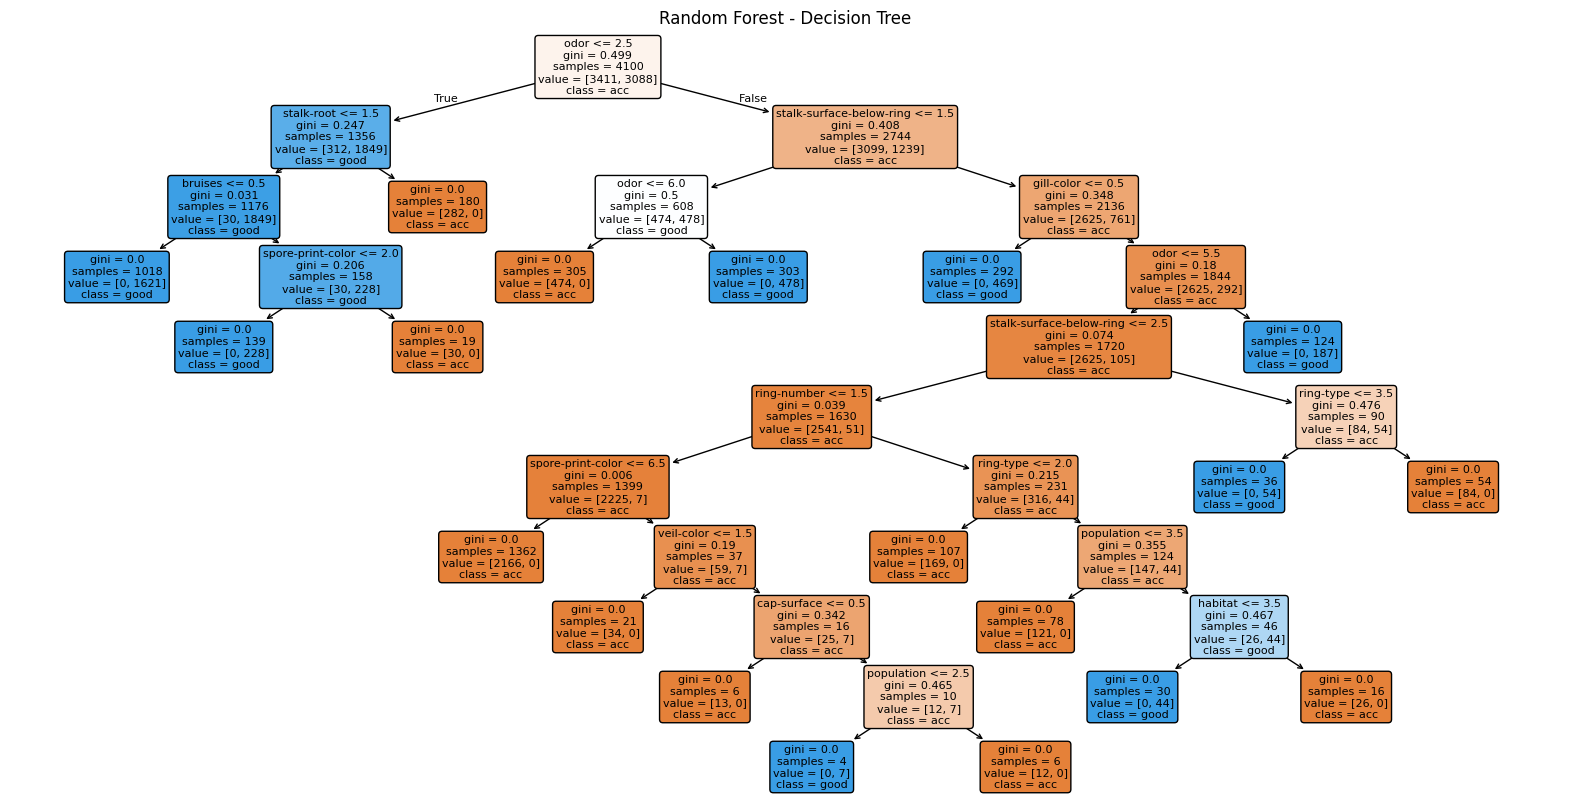

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model.estimators_[0],      # First tree in the forest
    feature_names=X.columns,
    class_names=["acc", "good", "unacc", "vgood"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Random Forest - Decision Tree")
plt.show()

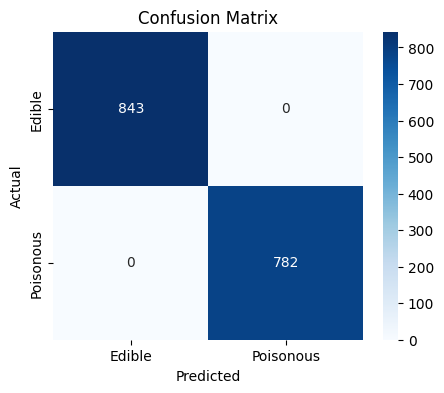

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Edible","Poisonous"],
    yticklabels=["Edible","Poisonous"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
19         spore-print-color    0.377421
8                 gill-color    0.273212
7                  gill-size    0.150903
10                stalk-root    0.103209
21                   habitat    0.026517
9                stalk-shape    0.025509
20                population    0.021792
4                       odor    0.021438
5            gill-attachment    0.000000
1                cap-surface    0.000000
0                  cap-shape    0.000000
3                    bruises    0.000000
2                  cap-color    0.000000
6               gill-spacing    0.000000
13    stalk-color-above-ring    0.000000
12  stalk-surface-below-ring    0.000000
11  stalk-surface-above-ring    0.000000
14    stalk-color-below-ring    0.000000
17               ring-number    0.000000
16                veil-color    0.000000
15                 veil-type    0.000000
18                 ring-type    0.000000


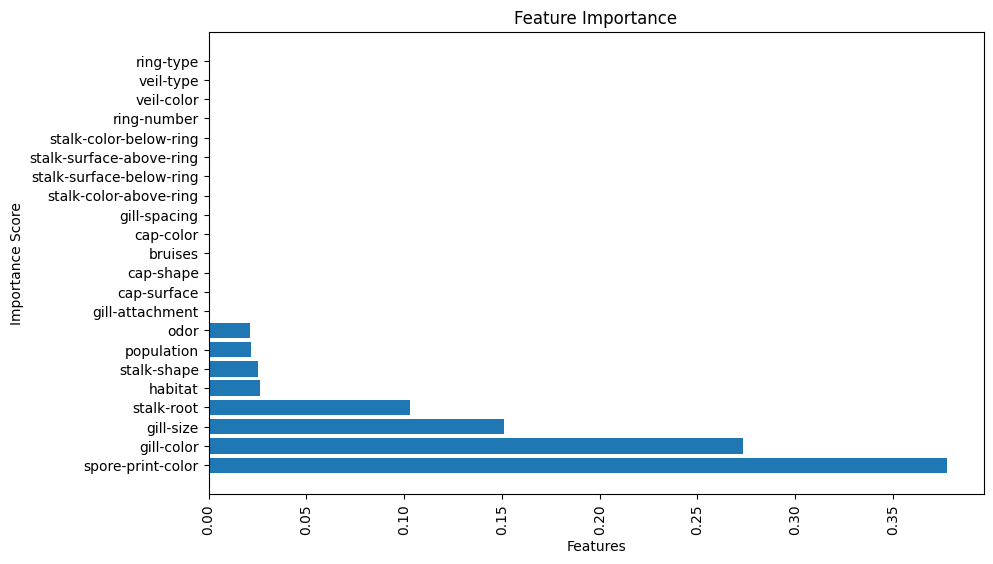

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create DataFrame for feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(by="Importance", ascending=False)

# Plot Bar Graph
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)

plt.show()

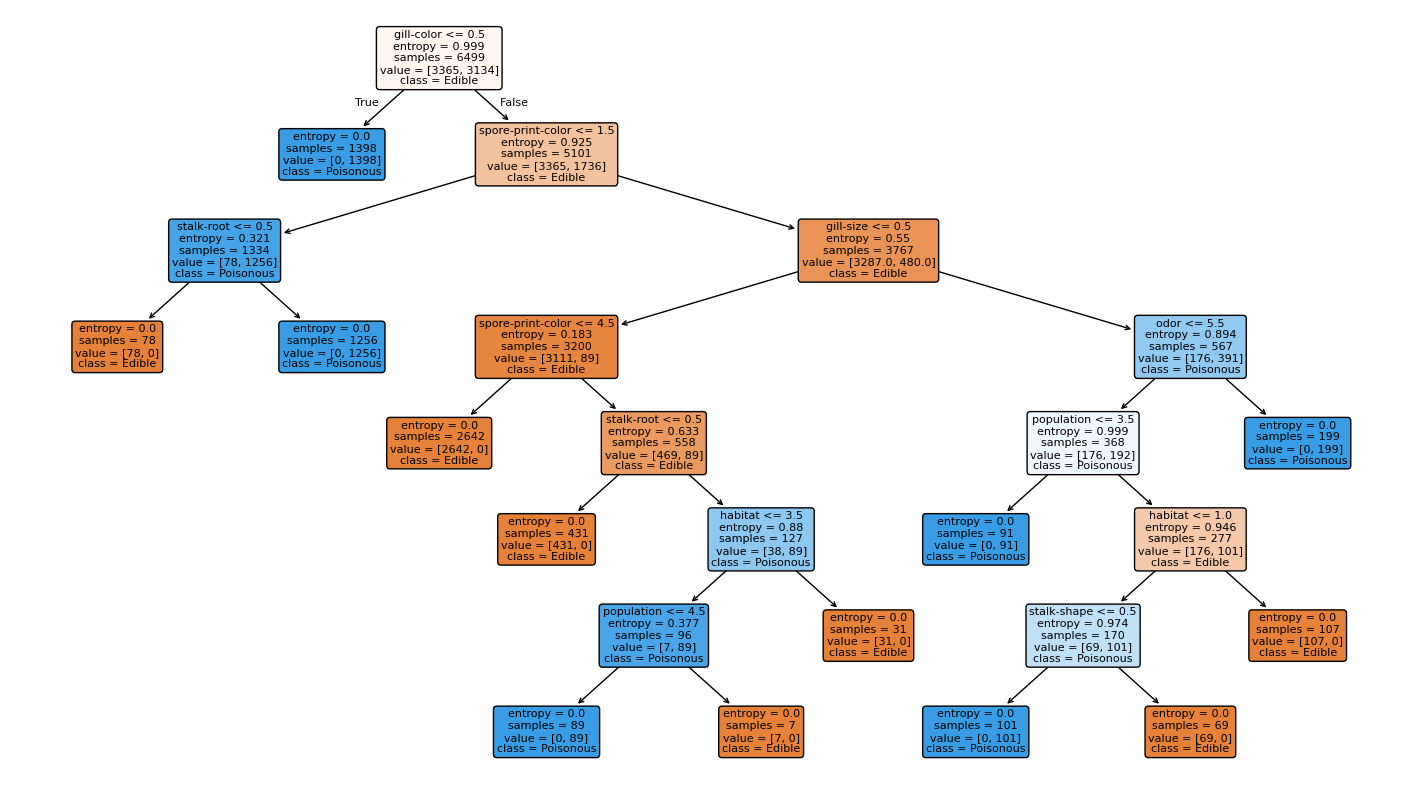

In [ ]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Edible","Poisonous"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


In [ ]:
new_data = [[5, 2, 4, 1, 3, 0, 1, 2, 4, 1, 0, 2, 2, 4, 4, 0, 1, 1, 3, 2, 4, 5]]

prediction = model.predict(new_data)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv(os.path.join(path, "mushrooms.csv"))
# Encode all categorical columns
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("class", axis=1)
y = df["class"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


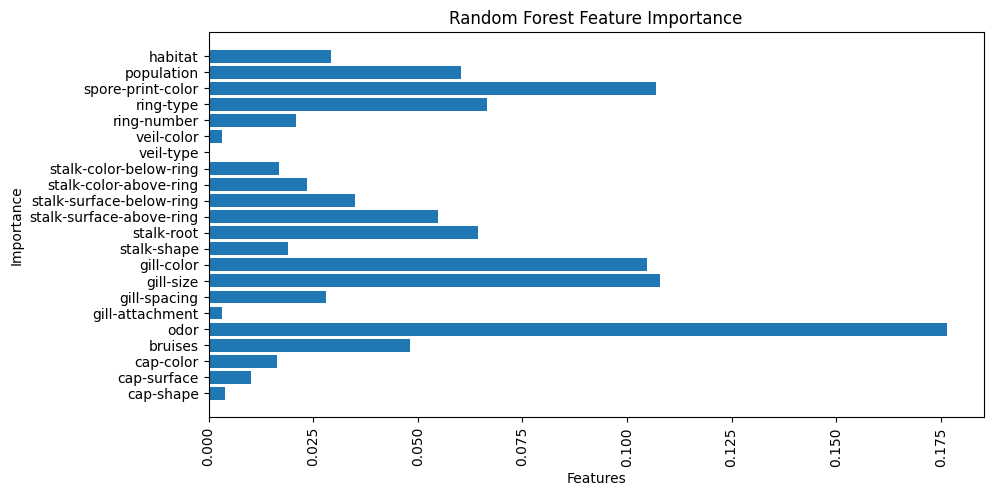

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(X.columns, importance)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()